In [ ]:
!pip install -U datasets huggingface_hub pyarrow -q

In [ ]:
!pip install nltk -q

In [ ]:
!pip install wordcloud -q

In [ ]:
!pip install transformers datasets accelerate evaluate -q

# IMDB Sentiment Analysis using TF-IDF and DistilBERT

## Project Overview

This project focuses on binary sentiment classification of movie reviews using the IMDB dataset, consisting of 50,000 labeled reviews evenly distributed between positive and negative sentiment classes. The objective is to compare traditional machine learning approaches with transformer-based deep learning models for sentiment analysis.

The workflow begins with exploratory data analysis (EDA) to understand review characteristics, sentiment distribution, and commonly occurring words. Text preprocessing techniques such as HTML tag removal, lowercasing, and punctuation cleaning are applied before converting reviews into numerical representations using TF-IDF vectorization.

Two classical machine learning models, Logistic Regression and LinearSVC, are trained as strong baseline models. Subsequently, a DistilBERT transformer model is fine-tuned using the Hugging Face Transformers library to leverage contextual language understanding for improved sentiment prediction.

The project evaluates all models using Accuracy, F1-Score, and AUC-ROC metrics, analyzes influential sentiment words from TF-IDF coefficients, and deploys the final DistilBERT model through a Gradio web application hosted on Hugging Face Spaces for real-time inference.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import evaluate
import torch

from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)

#Dataset Loading

In [ ]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

In [ ]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [ ]:
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (25000, 2)
Test shape: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


#Exploratory Data Analysis

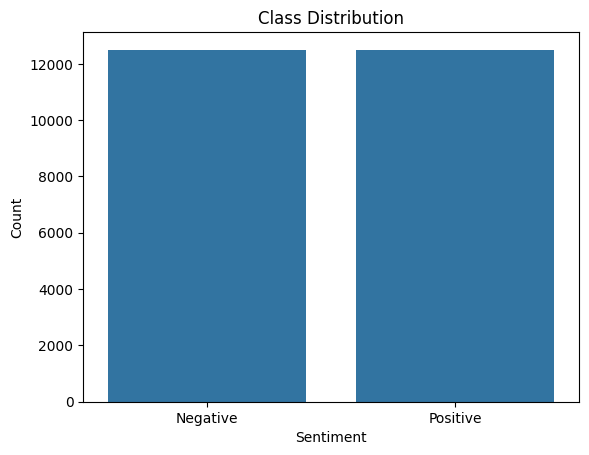

In [ ]:
sns.countplot(x="label", data=train_df)

plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.xticks([0, 1], ["Negative", "Positive"])

plt.show()

In [ ]:
train_df["review_length"] = train_df["text"].apply(
    lambda x: len(x.split())
)

train_df["review_length"].describe()

,review_length
count,25000.000000
mean,233.787200
std,173.733032
min,10.000000
25%,127.000000
50%,174.000000
75%,284.000000
max,2470.000000


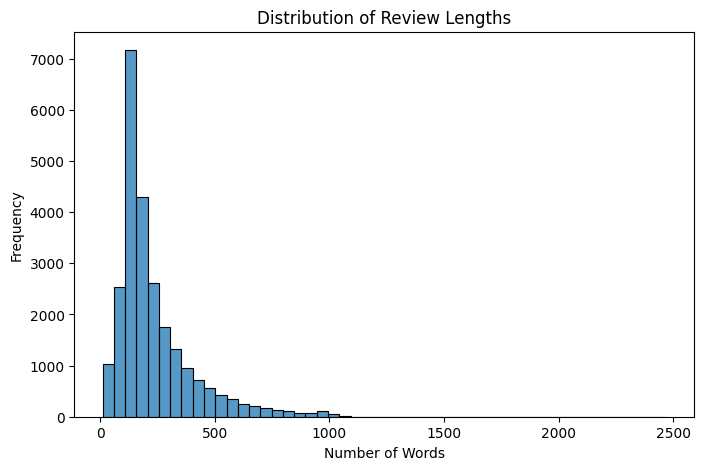

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["review_length"],
    bins=50
)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

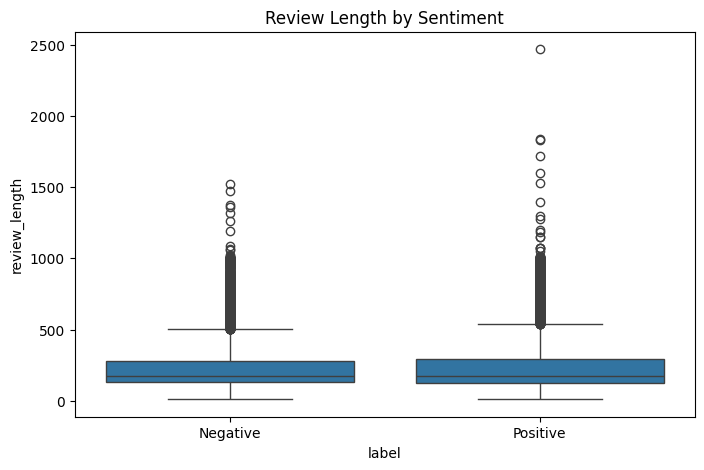

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="review_length",
    data=train_df
)

plt.xticks([0,1], ["Negative", "Positive"])

plt.title("Review Length by Sentiment")

plt.show()

In [ ]:
avg_lengths = train_df.groupby("label")["review_length"].mean()

print("Average Review Lengths")
print(avg_lengths)

Average Review Lengths
label
0    230.86784
1    236.70656
Name: review_length, dtype: float64


In [ ]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import re
import string

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

train_df[["text", "clean_text"]].head()

,text,clean_text
0,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curiousyellow from my video stor...
1,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...
2,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...
3,This film was probably inspired by Godard's Ma...,this film was probably inspired by godards mas...
4,"Oh, brother...after hearing about this ridicul...",oh brotherafter hearing about this ridiculous ...


In [ ]:
custom_stopwords = stop_words.union({
    "movie","film","one","would","could",
    "really","also","get","even","much",
    "time","first","see","make","made",
    "people","br","movies"
})

In [ ]:
positive_text = " ".join(
    train_df[train_df["label"] == 1]["clean_text"]
)

words = [
    word.lower()
    for word in positive_text.split()
    if word.lower() not in custom_stopwords
]

common_words = Counter(words).most_common(20)

common_words

[('like', 8750),
 ('good', 7478),
 ('story', 6603),
 ('great', 6333),
 ('well', 5707),
 ('films', 4326),
 ('best', 4255),
 ('love', 4194),
 ('way', 3972),
 ('life', 3907),
 ('many', 3753),
 ('characters', 3661),
 ('think', 3632),
 ('two', 3617),
 ('seen', 3390),
 ('watch', 3371),
 ('little', 3324),
 ('dont', 3313),
 ('still', 3310),
 ('show', 3308)]

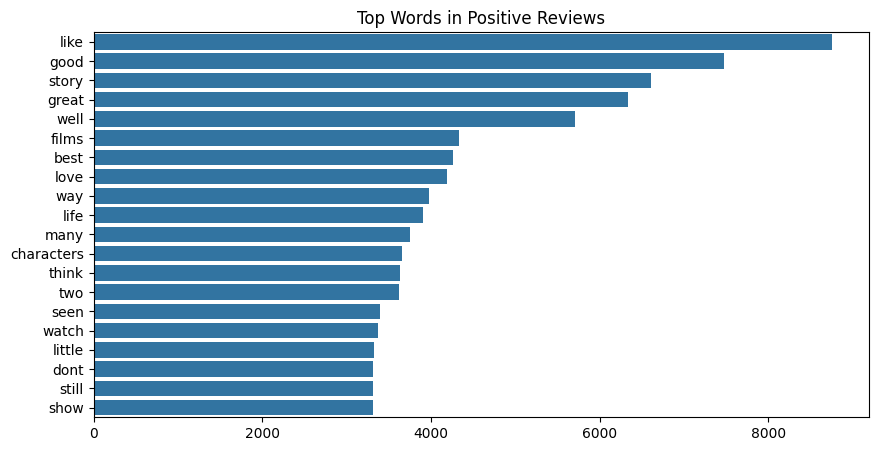

In [ ]:
words, counts = zip(*common_words)

plt.figure(figsize=(10,5))

sns.barplot(
    x=list(counts),
    y=list(words)
)

plt.title("Top Words in Positive Reviews")

plt.show()

In [ ]:
negative_text = " ".join(
    train_df[train_df["label"] == 0]["clean_text"]
)

words = [
    word.lower()
    for word in negative_text.split()
    if word.lower() not in custom_stopwords
]

common_words_neg = Counter(words).most_common(20)

common_words_neg

[('like', 10928),
 ('good', 7232),
 ('bad', 7209),
 ('dont', 5169),
 ('story', 5071),
 ('plot', 4023),
 ('acting', 3978),
 ('way', 3898),
 ('well', 3873),
 ('characters', 3741),
 ('think', 3626),
 ('films', 3518),
 ('watch', 3510),
 ('better', 3320),
 ('know', 3299),
 ('character', 3288),
 ('seen', 3238),
 ('never', 3230),
 ('ever', 3203),
 ('little', 3076)]

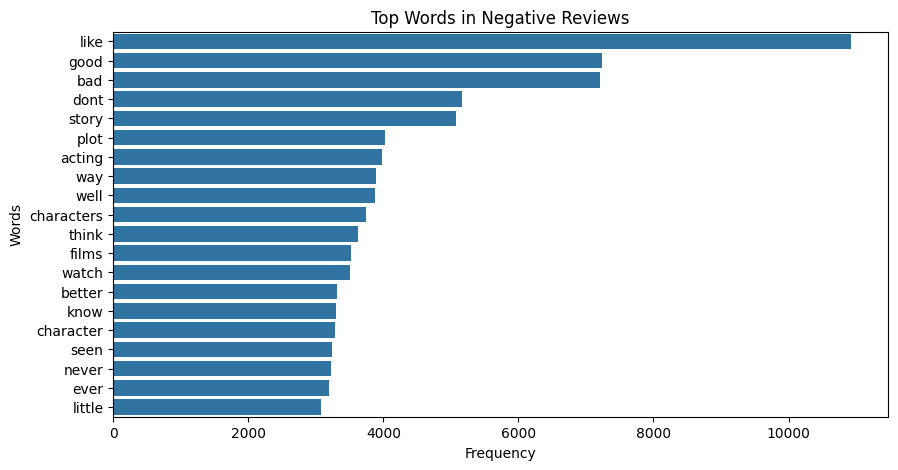

In [ ]:
words_neg, counts_neg = zip(*common_words_neg)

plt.figure(figsize=(10,5))

sns.barplot(
    x=list(counts_neg),
    y=list(words_neg)
)

plt.title("Top Words in Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

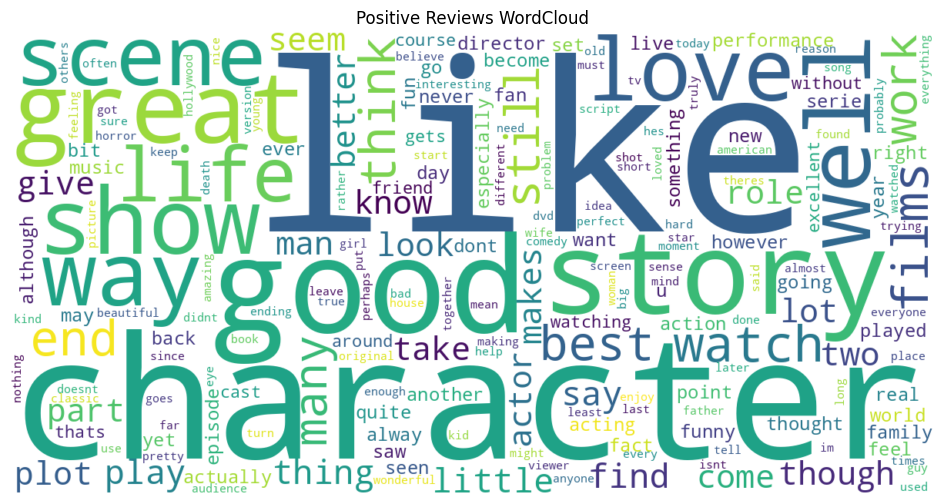

In [ ]:
positive_text = " ".join(
    train_df[train_df["label"] == 1]["clean_text"]
)

wordcloud_pos = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

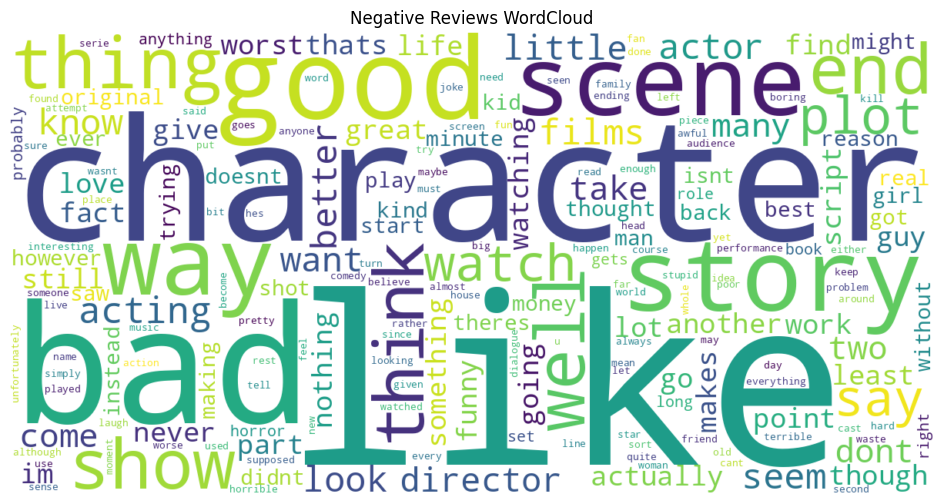

In [ ]:
negative_text = " ".join(
    train_df[train_df["label"] == 0]["clean_text"]
)

wordcloud_neg = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews WordCloud")
plt.show()

#Text Preprocessing Pipeline

###TF-IDF Vectorization

In [ ]:
X_train_text = train_df["clean_text"]
X_test_text = test_df["clean_text"]

y_train = train_df["label"]
y_test = test_df["label"]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (25000, 10000)
Test TF-IDF shape: (25000, 10000)


In [ ]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:20])

['010' '10' '10 10' '10 lines' '10 minutes' '10 stars' '10 year'
 '10 years' '100' '100 years' '1000' '101' '1010' '11' '110' '12'
 '12 years' '13' '13th' '14']


In [ ]:
print(type(X_train_tfidf))
print(X_train_tfidf.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(25000, 10000)


#Model training

###Logistic Regression Baseline

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test_tfidf)

y_prob_lr = lr.predict_proba(X_test_tfidf)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
auc = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.8831
F1 Score : 0.8837
AUC-ROC  : 0.9535

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.88     12500
           1       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



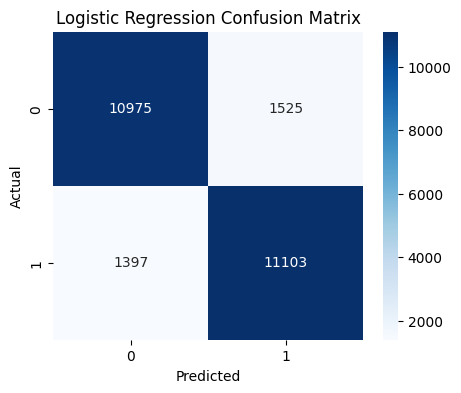

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

###LinearSVC Baseline

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    random_state=42
)

svm.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [ ]:
y_pred_svm = svm.predict(X_test_tfidf)

In [ ]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f"Accuracy : {accuracy_svm:.4f}")
print(f"F1 Score : {f1_svm:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy : 0.8699
F1 Score : 0.8686

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.88      0.87     12500
           1       0.88      0.86      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



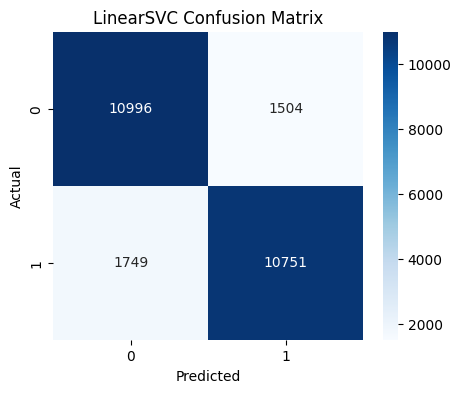

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("LinearSVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
feature_names = tfidf.get_feature_names_out()

In [ ]:
coef = lr.coef_[0]

top_positive_idx = np.argsort(coef)[-20:]

positive_words = pd.DataFrame({
    "Word": feature_names[top_positive_idx],
    "Coefficient": coef[top_positive_idx]
}).sort_values(
    by="Coefficient",
    ascending=False
)

positive_words

,Word,Coefficient
19,great,6.386406
18,excellent,5.980719
17,best,4.864897
16,wonderful,4.662000
15,perfect,4.627436
14,amazing,4.215889
13,favorite,4.187709
12,710,4.138670
11,fun,3.548584
10,loved,3.493964


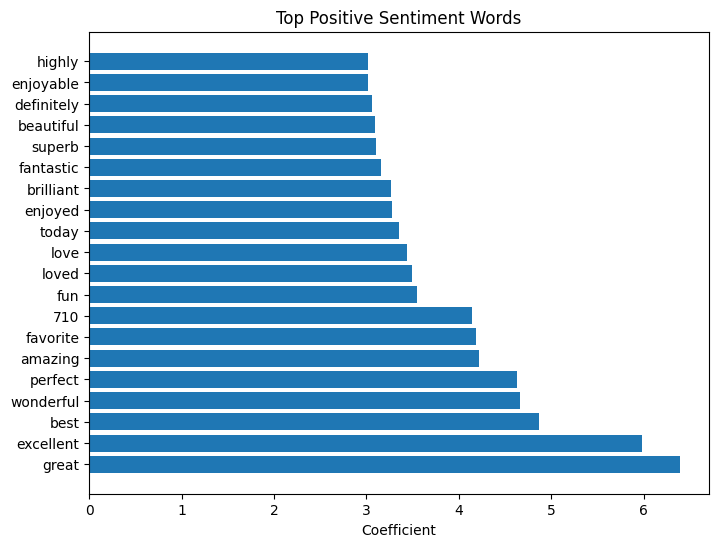

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(
    positive_words["Word"],
    positive_words["Coefficient"]
)

plt.title("Top Positive Sentiment Words")
plt.xlabel("Coefficient")

plt.show()

In [ ]:
top_negative_idx = np.argsort(coef)[:20]

negative_words = pd.DataFrame({
    "Word": feature_names[top_negative_idx],
    "Coefficient": coef[top_negative_idx]
}).sort_values(
    by="Coefficient"
)

negative_words

,Word,Coefficient
0,worst,-8.433714
1,bad,-6.737957
2,awful,-6.273938
3,waste,-5.679833
4,boring,-5.412429
5,poor,-4.982336
6,worse,-4.805068
7,dull,-4.423996
8,terrible,-4.383838
9,poorly,-4.324633


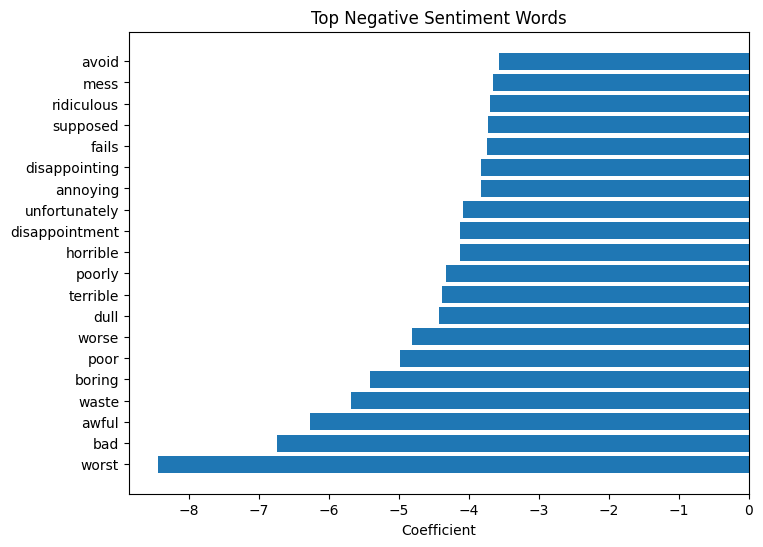

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(
    negative_words["Word"],
    negative_words["Coefficient"]
)

plt.title("Top Negative Sentiment Words")
plt.xlabel("Coefficient")

plt.show()

###DistilBERT fine-tuning

In [ ]:
train_hf = Dataset.from_pandas(
    train_df[["clean_text", "label"]]
)

test_hf = Dataset.from_pandas(
    test_df[["clean_text", "label"]]
)

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [ ]:
train_hf = train_hf.map(
    tokenize,
    batched=True
)

test_hf = test_hf.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
cols_to_remove = [
    col
    for col in train_hf.column_names
    if col not in ["label", "input_ids", "attention_mask"]
]

train_hf = train_hf.remove_columns(cols_to_remove)
test_hf = test_hf.remove_columns(cols_to_remove)

train_hf.set_format("torch")
test_hf.set_format("torch")

In [ ]:
print(train_hf)
print(test_hf)

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 25000
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 25000
})


In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import evaluate
import numpy as np
from sklearn.metrics import roc_auc_score

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    probs = np.exp(logits) / np.exp(logits).sum(
        axis=1,
        keepdims=True
    )

    acc = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels
    )

    auc = roc_auc_score(
        labels,
        probs[:, 1]
    )

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "auc": auc
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    warmup_steps=500,

    weight_decay=0.01,

    logging_steps=200,

    load_best_model_at_end=True,

    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_hf,
    eval_dataset=test_hf,

    compute_metrics=compute_metrics
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,0.220459,0.259133,0.902880,0.898376,0.971581
2,0.154348,0.347142,0.898680,0.893028,0.970431
3,0.097686,0.362405,0.913240,0.913139,0.971768


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4689, training_loss=0.1606417713096132, metrics={'train_runtime': 2371.326, 'train_samples_per_second': 31.628, 'train_steps_per_second': 1.977, 'total_flos': 4967527449600000.0, 'train_loss': 0.1606417713096132, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,F1,Auc
0.097686,0.259133,3,0.902880,0.898376,0.971581


{'eval_loss': 0.25913286209106445, 'eval_accuracy': 0.90288, 'eval_f1': 0.8983760254478487, 'eval_auc': 0.9715814463999999}


In [ ]:
predictions = trainer.predict(test_hf)

y_pred_bert = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

In [ ]:
print(
    classification_report(
        y_true,
        y_pred_bert
    )
)

              precision    recall  f1-score   support

           0       0.87      0.95      0.91     12500
           1       0.94      0.86      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.91      0.90      0.90     25000
weighted avg       0.91      0.90      0.90     25000



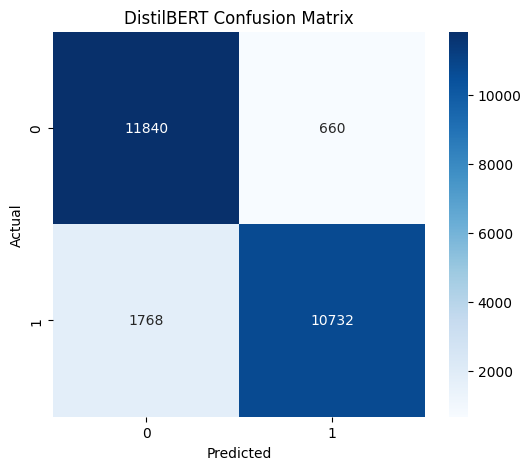

In [ ]:
cm_bert = confusion_matrix(
    y_true,
    y_pred_bert
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

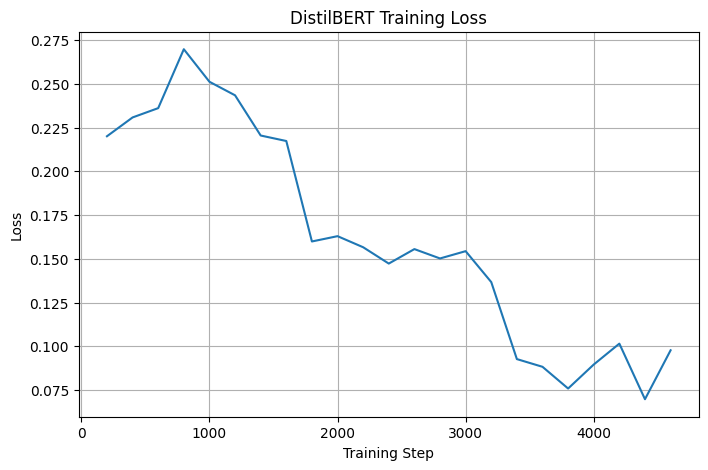

In [ ]:
history = pd.DataFrame(
    trainer.state.log_history
)

loss_df = history[
    history["loss"].notna()
]

plt.figure(figsize=(8,5))

plt.plot(
    loss_df["step"],
    loss_df["loss"]
)

plt.title("DistilBERT Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

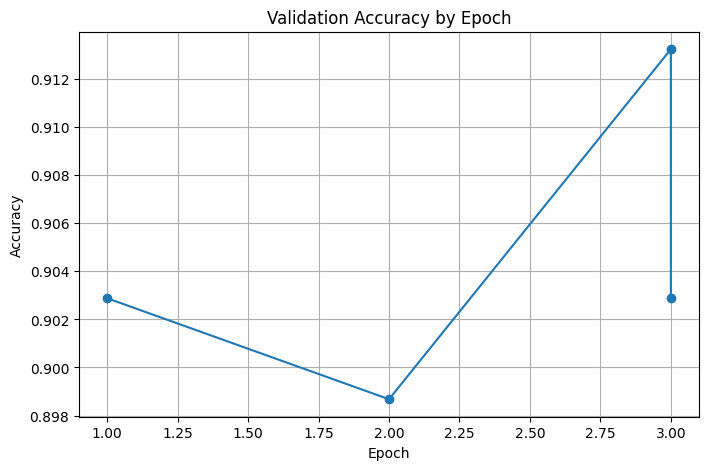

In [ ]:
eval_df = history[
    history["eval_accuracy"].notna()
]

plt.figure(figsize=(8,5))

plt.plot(
    eval_df["epoch"],
    eval_df["eval_accuracy"],
    marker="o"
)

plt.title("Validation Accuracy by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

#Evaluation and Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (TF-IDF)",
        "LinearSVC (TF-IDF)",
        "DistilBERT"
    ],
    "Accuracy": [
        0.8831,
        0.8699,
        results["eval_accuracy"]
    ],
    "F1 Score": [
        0.8837,
        0.8686,
        results["eval_f1"]
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Logistic Regression (TF-IDF),0.88310,0.883700
1,LinearSVC (TF-IDF),0.86990,0.868600
2,DistilBERT,0.90288,0.898376


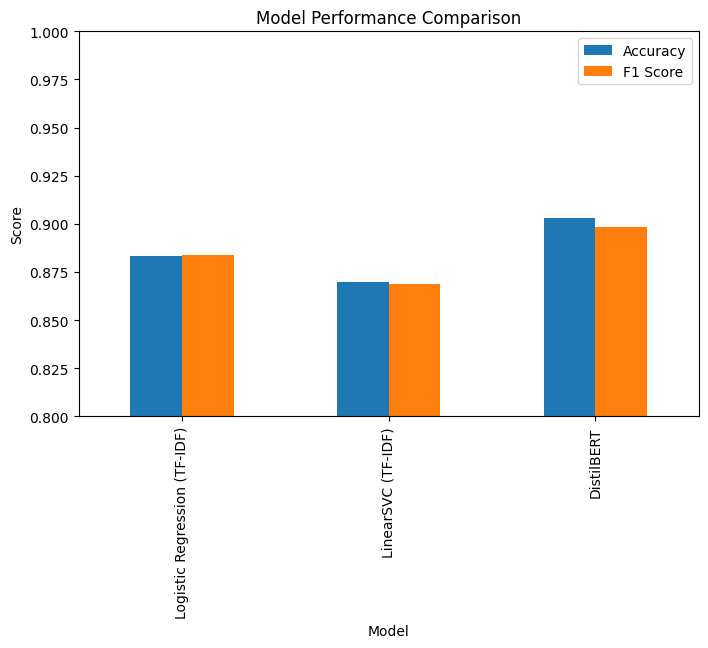

In [ ]:
import matplotlib.pyplot as plt

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)

plt.show()

In [2]:
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizerFast
)

model = DistilBertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/distilbert_imdb"
)

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "/content/drive/MyDrive/distilbert_imdb"
)

Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

In [3]:
import torch

def predict_sentiment(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)[0]

    confidence = float(probs.max())

    prediction = (
        "Positive"
        if probs.argmax().item() == 1
        else "Negative"
    )

    return prediction, confidence

In [4]:
print(predict_sentiment(
    "This movie was absolutely amazing. I loved every minute of it."
))

('Positive', 0.9896272420883179)


In [5]:
print(predict_sentiment(
    "This was the worst movie I have ever seen."
))

('Negative', 0.9914041757583618)


## Conclusion

This project demonstrates the effectiveness of both classical NLP techniques and transformer-based models for sentiment analysis. TF-IDF combined with Logistic Regression established a strong baseline, achieving 88.31% accuracy and 88.37% F1-score on the IMDB test set.

Fine-tuning DistilBERT further improved performance, achieving 90.29% accuracy, 89.84% F1-score, and 97.16% AUC-ROC. The transformer model's ability to capture contextual relationships, semantic meaning, and long-range dependencies enabled it to outperform traditional bag-of-words approaches.

Analysis of TF-IDF feature weights revealed highly predictive sentiment terms such as "great", "excellent", and "wonderful" for positive reviews, and "worst", "awful", and "boring" for negative reviews. The final model was successfully deployed using Gradio and Hugging Face Spaces, enabling real-time sentiment prediction through an interactive web interface.

Overall, the project highlights the progression from classical machine learning to modern transformer architectures and demonstrates the complete machine learning lifecycle, including data analysis, model development, evaluation, interpretation, and deployment.

#Deployment with Gradio

Live Demo:
https://huggingface.co/spaces/shravani15/imdb-sentiment-analysis

In [6]:
!pip install gradio -q

In [ ]:
import gradio as gr

def gradio_predict(text):
    prediction, confidence = predict_sentiment(text)

    return (
        prediction,
        f"{confidence:.2%}"
    )

demo = gr.Interface(
    fn=gradio_predict,

    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter a movie review..."
    ),

    outputs=[
        gr.Textbox(label="Sentiment"),
        gr.Textbox(label="Confidence")
    ],

    title="IMDB Sentiment Analysis",
    description="DistilBERT fine-tuned on IMDB movie reviews"
)

demo.launch()